Project 
End-to-End E-commerce Intelligence System: Building a Customer 360 Analytics Framework
 
1. Business Problem Statement
In modern e-commerce ecosystems, data is generated across multiple independent systems such as customer management, order processing, payments, product catalogs, seller networks, and customer feedback platforms. These datasets are typically fragmented and stored in separate tables, making it difficult to extract unified insights.
The objective of this project is to simulate a real-world data analytics scenario where you are required to:
Integrate multiple data sources into a unified analytical dataset 
Construct a Customer 360 View 
Analyze customer behavior, revenue patterns, and operational performance 
Identify key drivers of business growth and customer satisfaction 
Generate actionable, data-driven business recommendations 
This project reflects how data analysts and data scientists work in real organizations, where raw data must be transformed into meaningful insights before applying machine learning models.
 
2. Dataset Overview
You are provided with a multi-table e-commerce dataset consisting of the following files (renamed for simplicity):
Core Tables
customers.csv
Contains customer demographic and location information 
orders.csv
Central table containing order lifecycle details (purchase, delivery, timestamps) 
order_items.csv
Contains product-level details for each order 
payments.csv
Payment information including type and value 
reviews.csv
Customer feedback and review scores 
 
Supporting Tables
products.csv
Product details and categories 
sellers.csv
Seller-level information 
geolocation.csv
Geographic information (optional for advanced analysis) 
category_translation.csv
Mapping of product categories to English names 

=====================Orders==========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
original orders count:  99441
orders with duplicate customer_id:  0
one to one relationship between orders and customers 
=====================Customers========================
=====================Order_Item

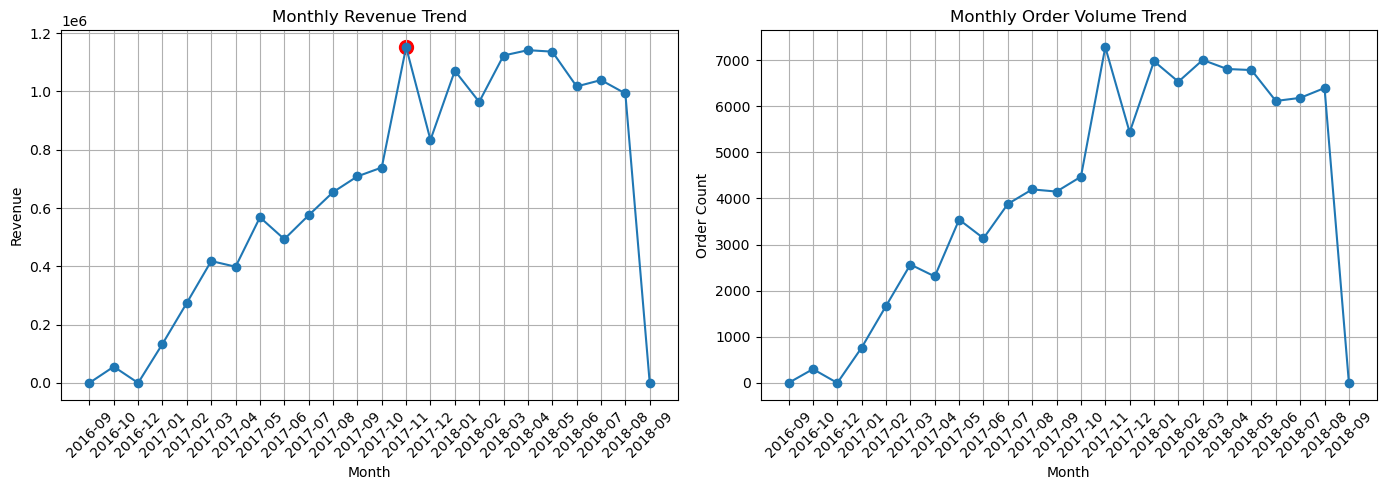

top5 catrgroies are: 0     agro_industry_and_commerce
45           musical_instruments
49               books_technical
50           luggage_accessories
51                  market_place
Name: category_name, dtype: object


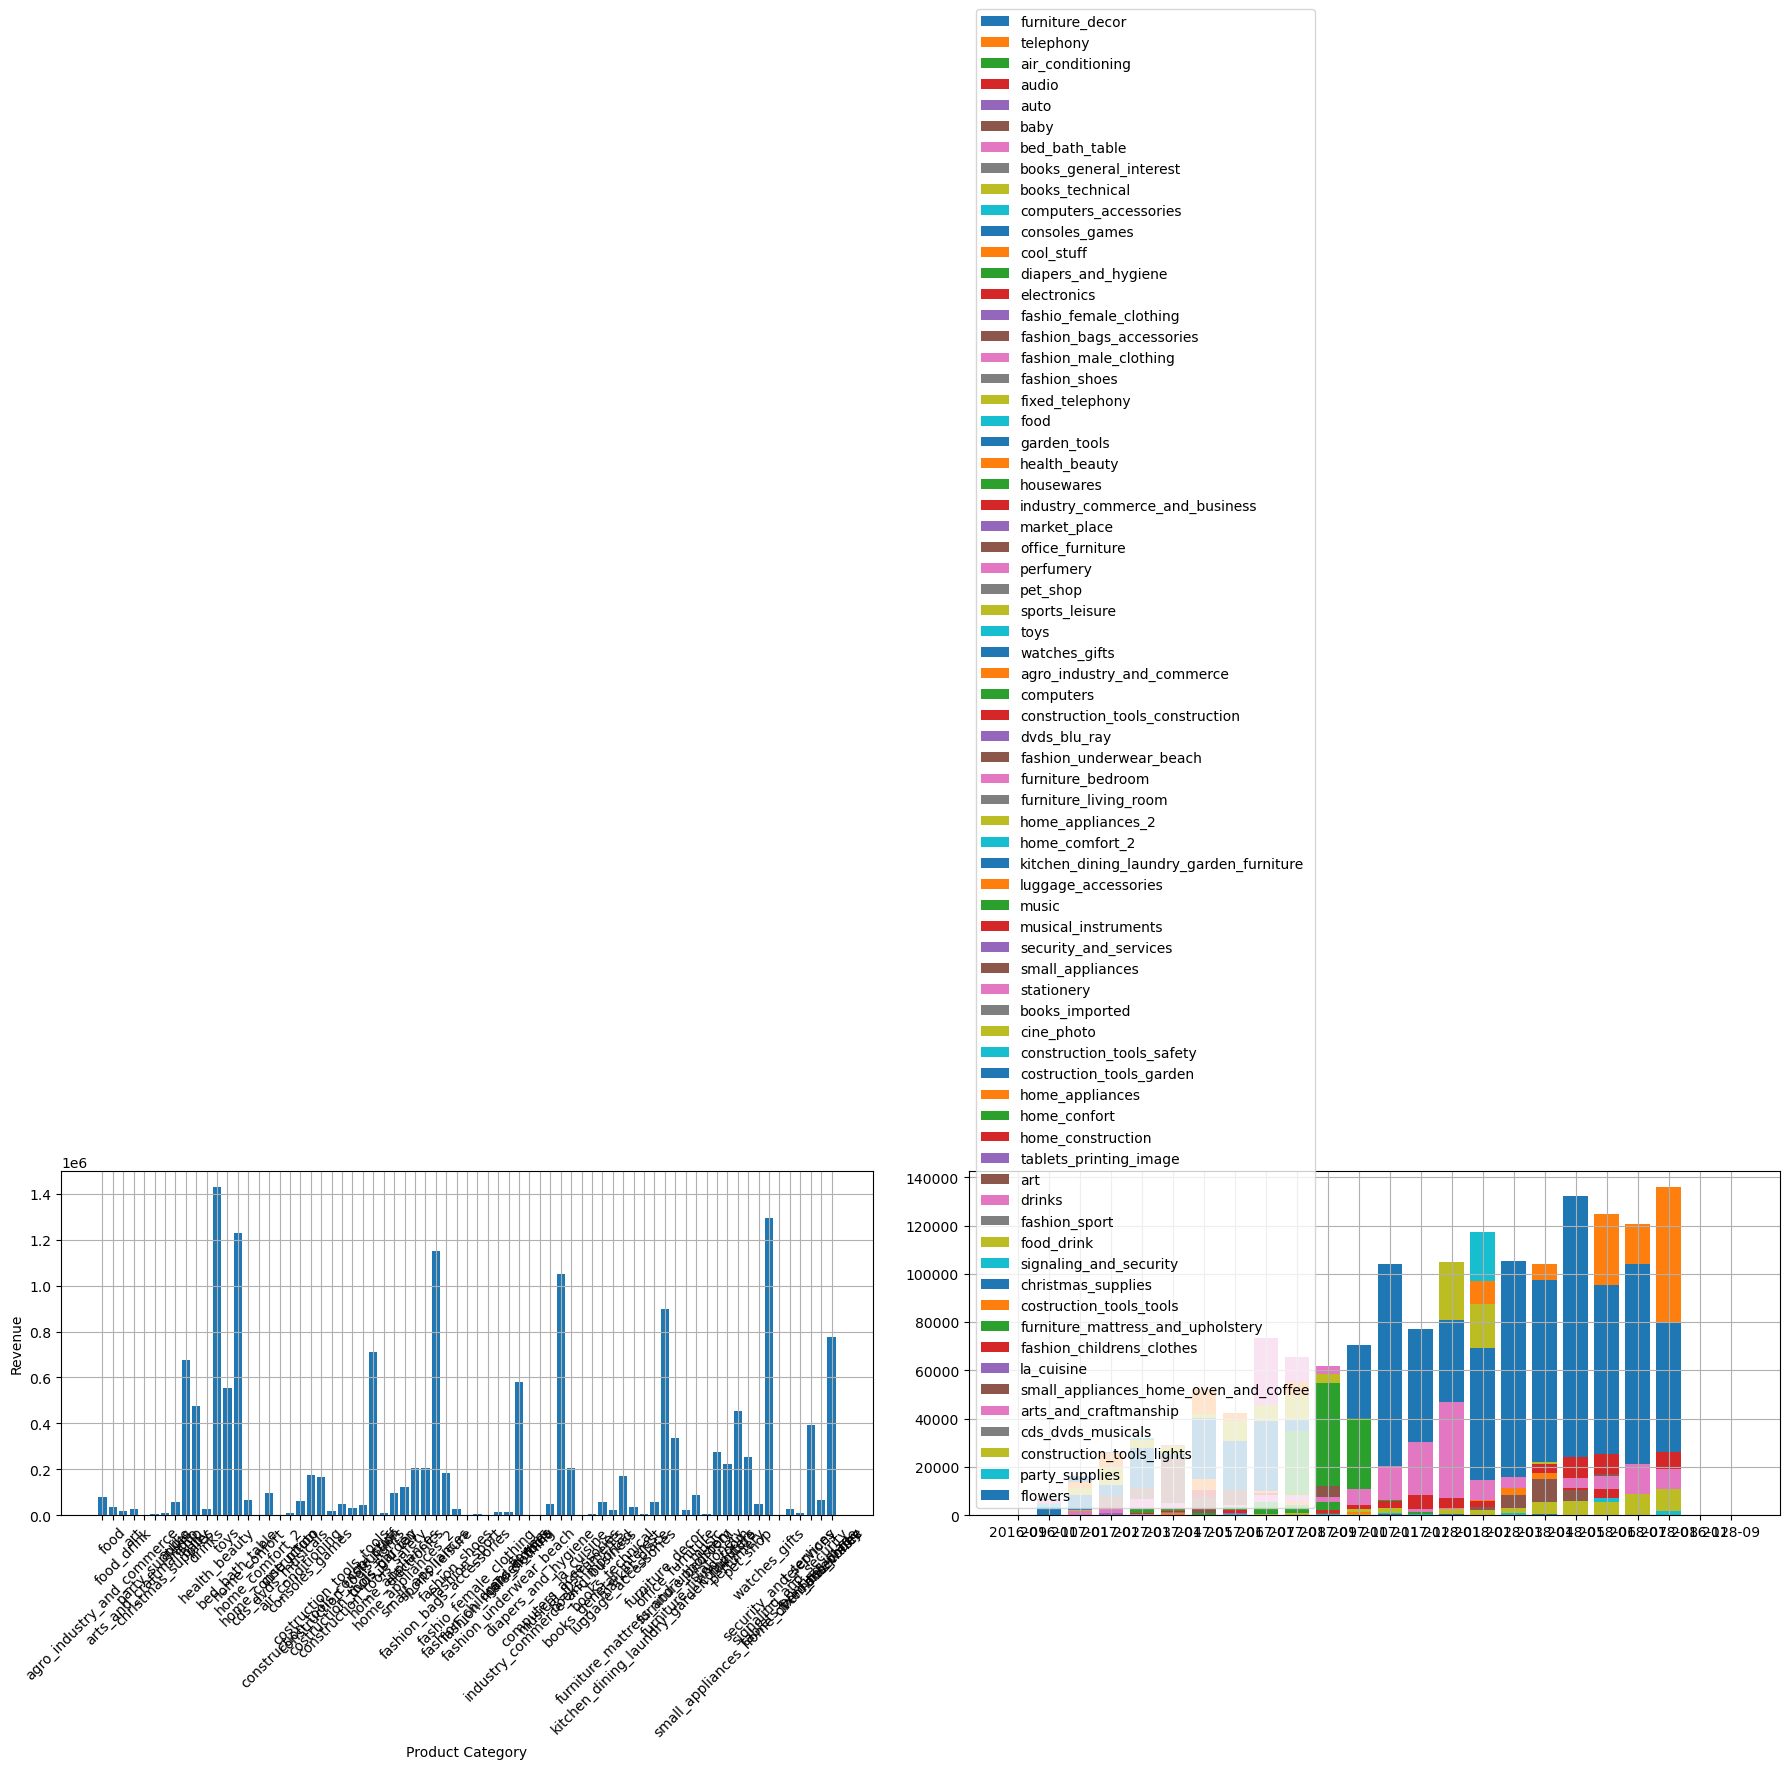

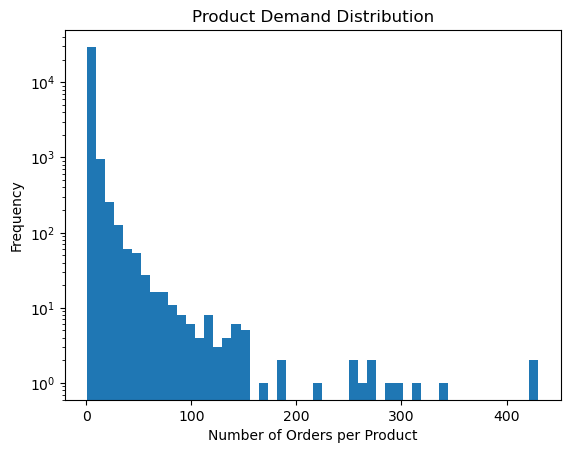

top10 sellers are:
 0       0015a82c2db000af6aaaf3ae2ecb0532
2006    aadfe0417e61315688b6bd7043361e25
2007    aae3bfea055532c57fb453ed3ec80b30
2008    aae5953b9edddf14749c0d65d60eb4b9
2009    aae5e7b457a3c72ee230a47d98fceda5
2010    aaed1309374718fdd995ee4c58c9dfcd
2011    aafe36600ce604f205b86b5084d3d767
2012    ab27bbbad5239bc31a34709275a70db4
2013    ab3e0c171fe84a7ba7de130f19cfb485
2015    ab91571efab27993ff2f6b36e38055c3
Name: seller_id, dtype: object


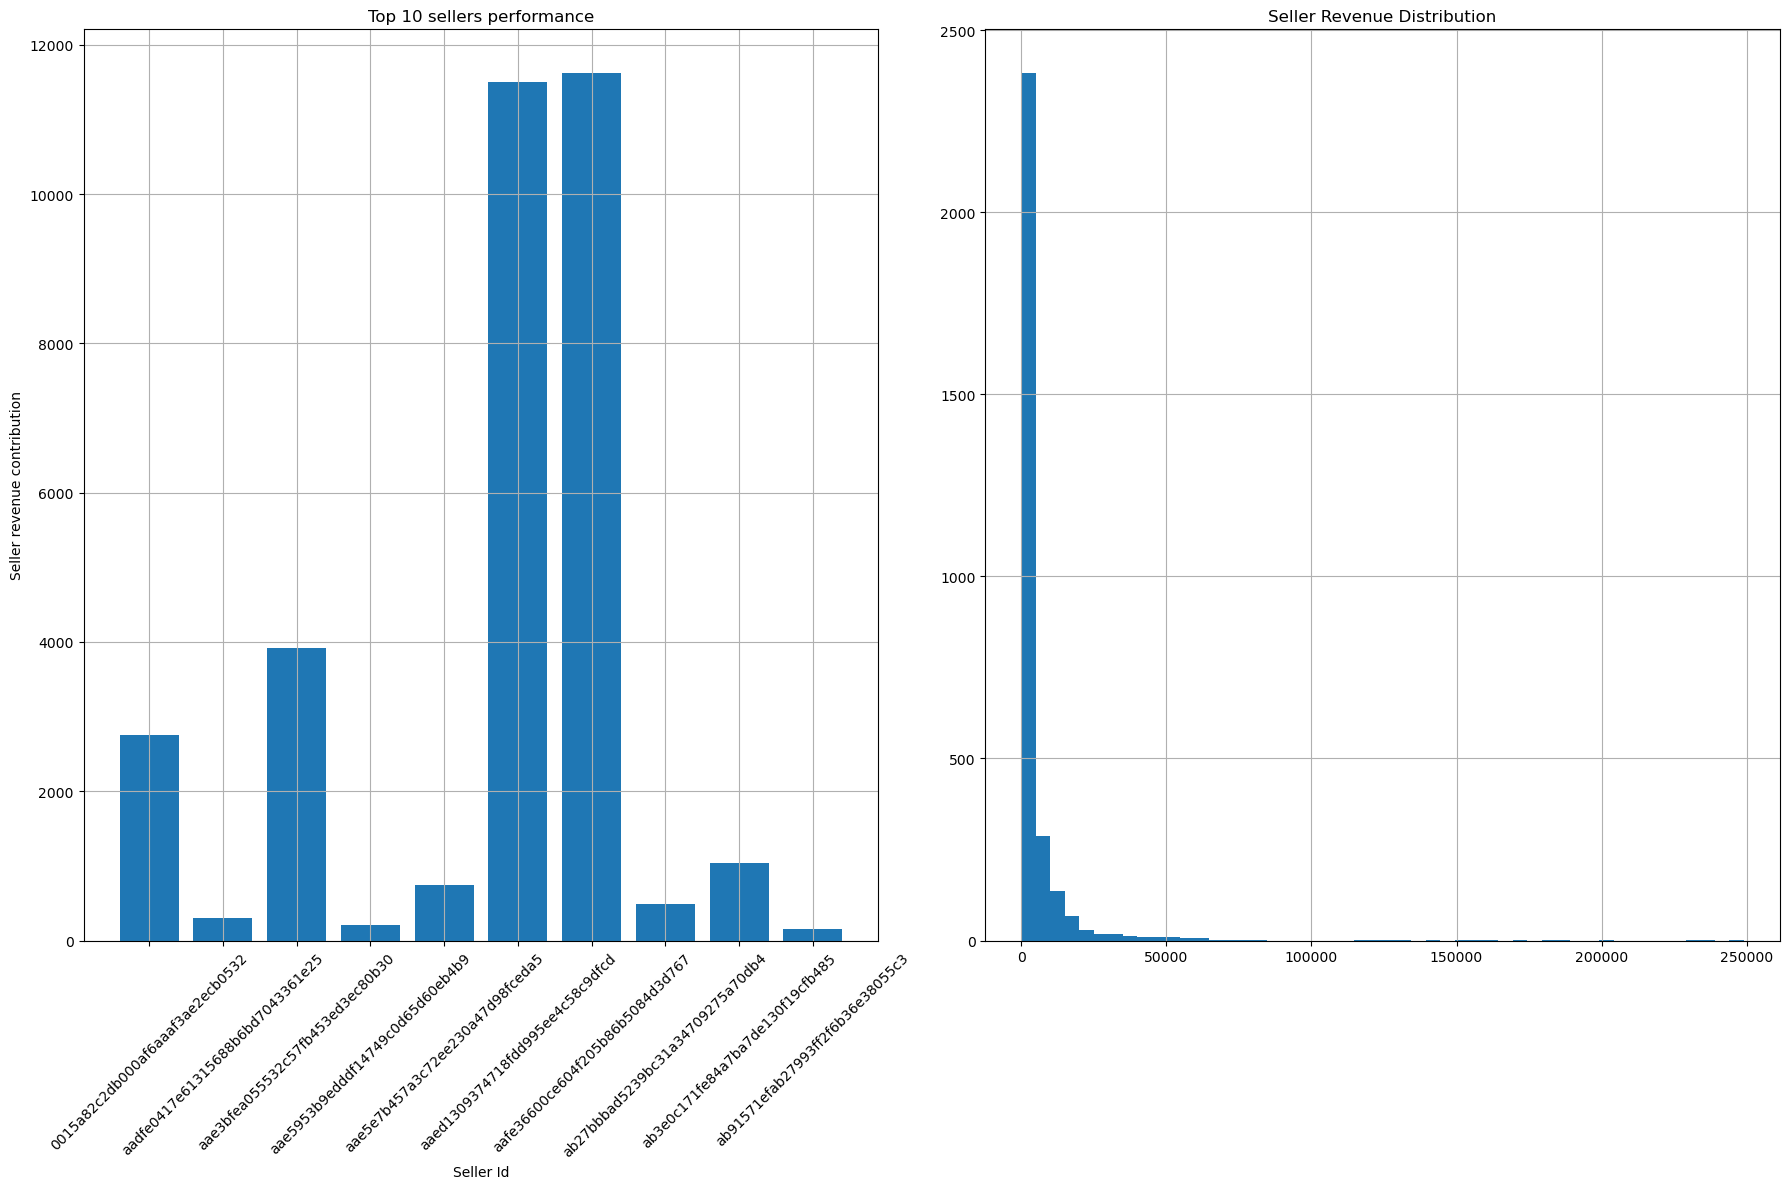

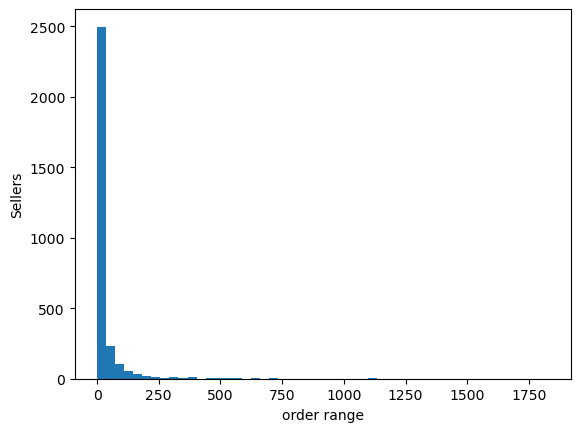

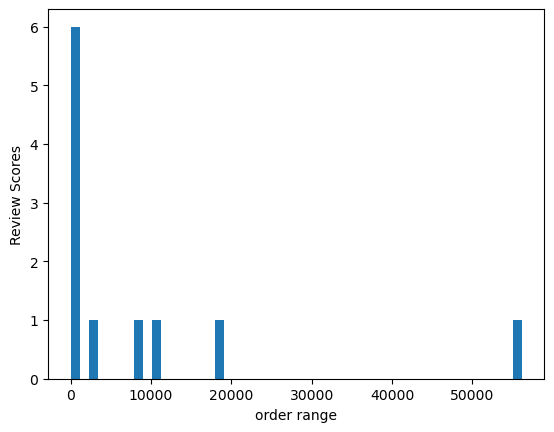

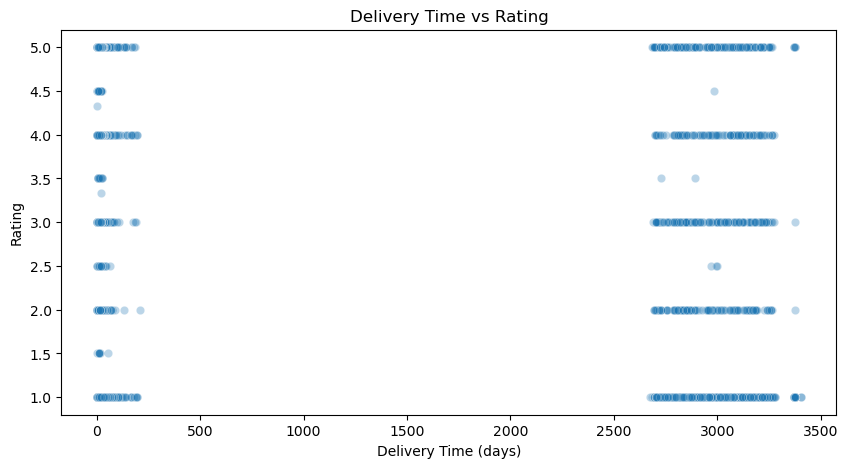

                    delivery_time_days  review_score
delivery_time_days            1.000000     -0.264246
review_score                 -0.264246      1.000000


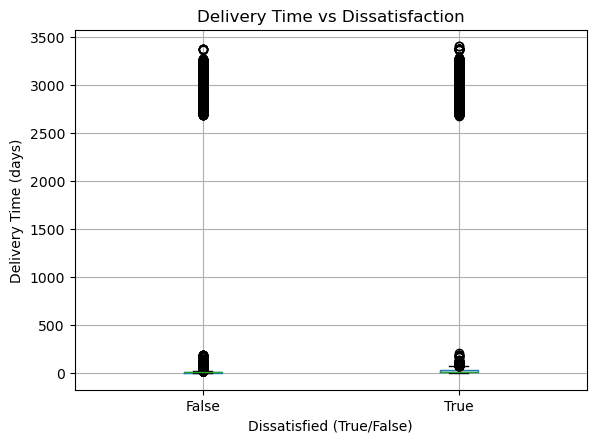

/var/folders/_d/wnx6skx965v3ctrg5fcbqf_c0000gn/T/ipykernel_2000/3508010921.py:530: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_pattern = master.groupby('delivery_range')['review_score'].mean()


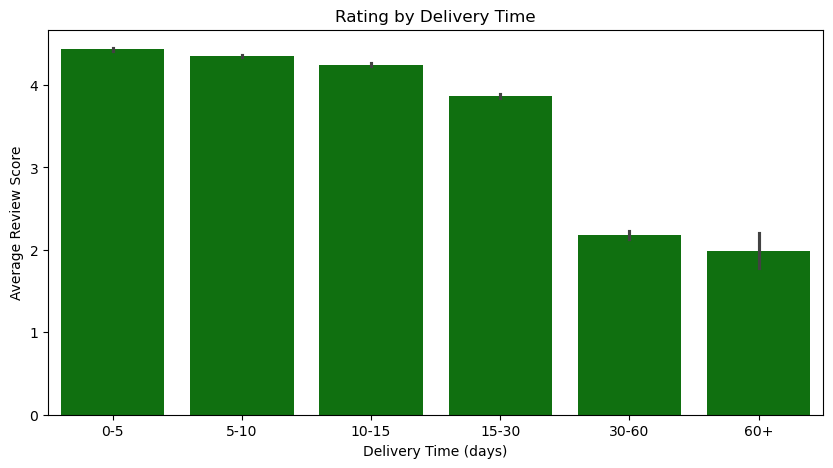

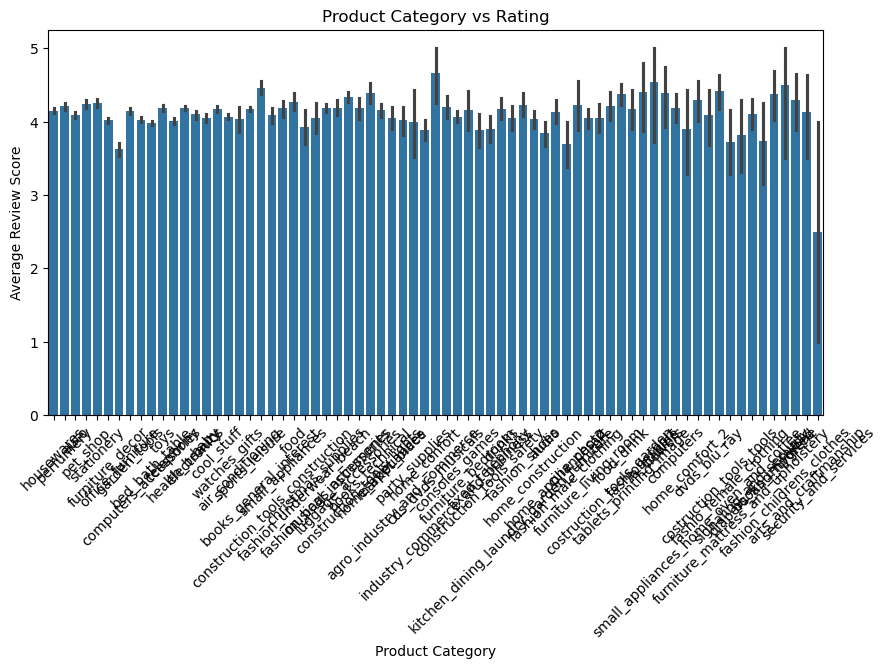

/var/folders/_d/wnx6skx965v3ctrg5fcbqf_c0000gn/T/ipykernel_2000/3508010921.py:576: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


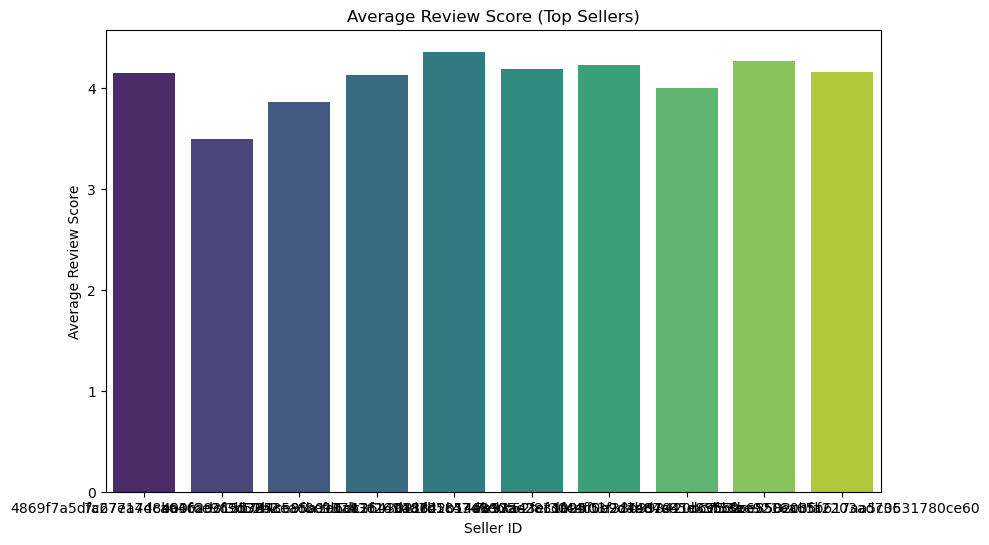

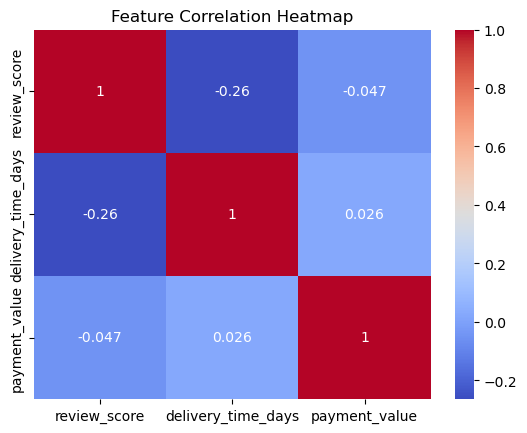

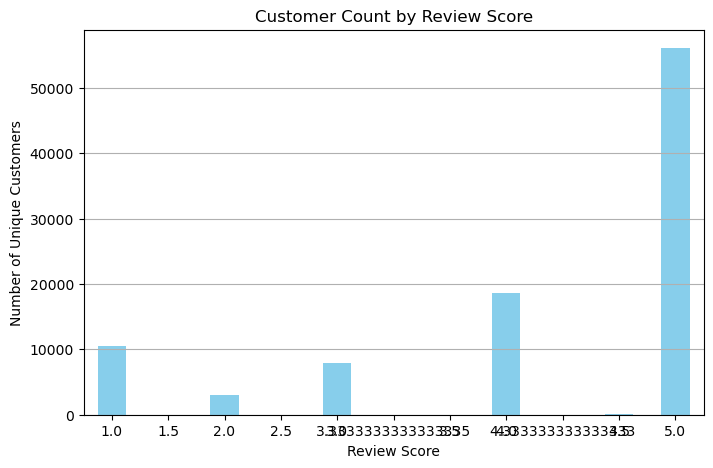

In [35]:
"""
Project Execution Guidelines
Step 1: Data Loading and Initial Exploration
Load all datasets using Pandas 
Inspect structure using .head(), .info(), .describe() 
Identify primary and foreign keys 
Understand relationships between tables 
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers= pd.read_csv("customers.csv")
orders= pd.read_csv("orders.csv")
oitems=pd.read_csv("order_item.csv")
payments=pd.read_csv("payments.csv")
reviews=pd.read_csv("reviews.csv")
products=pd.read_csv("products.csv")
sellers=pd.read_csv("sellers.csv")
location=pd.read_csv("location.csv")
category=pd.read_csv("category_translation.csv")

print("=====================Orders==========================", end="\n")
orders.head()
orders.info()
orders.describe()
print("=======================================================", end="\n")
# primary key order_id, foreign key customer_id
result = orders[orders.groupby('customer_id')['order_id'].transform('count') > 1]
print("original orders count: ",orders.shape[0], end="\n")
print("orders with duplicate customer_id: ",result.shape[0] , end="\n")
print("one to one relationship between orders and customers ", end="\n")
print("======================================================", end="\n")

print("=====================Customers========================", end="\n")
customers.head()
# primary key customer_id

print("=====================Order_Items========================", end="\n")

oitems.head()
# primary key order_item_id	
# foreign key order_id,product_id,seller_id
print("one to many relationship between order and items")
print("======================================================", end="\n")

print("=====================Payments=========================", end="\n")
payments.head()
# Primary and foreing key: Order_id
# one order to many payments
result1 = payments[payments.groupby('order_id')['payment_type'].transform('count') > 1]
print("original payments count: ",payments.shape[0])
print("payments with duplicate order_id: ",result1.shape[0])
print("one to many relationship between order and payments")
print("=====================================================", end="\n")


print("=====================Reviews=========================", end="\n")

reviews.head()
# primary key review_id, foregin key order_id
# one to many relationship between order and review
res3 = reviews[reviews.groupby('order_id')['review_id'].transform('count') > 1]
print("original reviews count: ",reviews.shape[0])
print("reviews with duplicate order_id: ",res3.shape[0])
print("one to many relationship between order and reviews")
print("=====================================================", end="\n")

print("=====================Products========================", end="\n")

products.head()
#primary key product_id
# one to many between product and order_items

print("=====================Sellers========================", end="\n")

sellers.head()
#primary key seller_id
# one to many between seller and order_items

location.head()
# city, state and zip suffix can be a composite key
#no direction relation to exsiting data but can be used to determien customer location

category.head()
#primary key product_category_name

"""
Step 2: Data Cleaning and Preprocessing
Handle missing values appropriately 
Remove duplicate records 
Convert date columns to datetime format 
Validate data types and ranges 
Standardize column names if required 
"""

#Pre processing orders df
#convert to datetime and fill na values to default date
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_approved_at'] = orders['order_approved_at'].fillna(pd.Timestamp('2026-01-01'))

orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_carrier_date'] = orders['order_delivered_carrier_date'].fillna(pd.Timestamp('2026-01-01'))

orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(pd.Timestamp('2026-01-01'))

orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

#standarize name
orders = orders.rename(columns={'order_purchase_timestamp': 'order_purchase_date'})
orders = orders.rename(columns={'order_approved_at': 'order_approved_date'})
#remove duplicates
orders = orders.drop_duplicates()
customers = customers.drop_duplicates()
oitems = oitems.drop_duplicates()
sellers = sellers.drop_duplicates()
payments = payments.drop_duplicates()
reviews = reviews.drop_duplicates()
category = category.drop_duplicates()
location = location.drop_duplicates()
print("=======Orders removed duplicates and feature engineering=========", end="\n")

orders.info()

# cleansing order_items df
oitems['shipping_limit_date'] = pd.to_datetime(oitems['shipping_limit_date'])

#cleansing reviews df
reviews.drop(columns=['review_comment_title'],inplace=True)
reviews['review_comment_message'] = reviews['review_comment_message'].fillna("No comment")

#cleansing product df
cols = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_description_lenght',
    'product_name_lenght'    
]
products[cols] = products[cols].fillna(products[cols].median())
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)


"""
Step 3: Data Integration (Critical Component)
You must construct a Master Dataset by merging multiple tables.
Recommended sequence:
orders + customers 
orders + order_items 
order_items + products 
orders + payments 
orders + reviews 
order_items + sellers 
products + category_translation 
Final output:
A single consolidated dataset representing a unified business view
"""

master=orders.merge(customers,on="customer_id")

pitems=oitems.merge(products,on="product_id", how="left")

# taking following feature name from Product table to describe order items

# total rows in each table
# orders : 99441
# customer : 99441
# items : 112650 (only 98666 has items record)
# products : 32951
# payments: 103886



items_agg = pitems.groupby('order_id').agg({
    'order_item_id': 'sum',
    'product_id': 'first',
    'product_category_name': 'first',
    'product_name_lenght': 'first',
    'product_description_lenght': 'first',
    'product_photos_qty': 'first',
    'price':'sum',
    'freight_value':'sum',
    'seller_id':'first',
    'shipping_limit_date': 'first'    
}).reset_index()


master = master.merge(items_agg, on='order_id')

# pitems['order_id'].nunique() shows only 98666 orders have items present 

# cols = [
#     'order_item_id',
#     'product_name_lenght',
#     'product_description_lenght',
#     'product_photos_qty',
#     'price',
#     'freight_value'
# ]
# colsNA = [
#     'product_category_name',
#     'seller_id',
#     'shipping_limit_date'
# ]

# master[cols] = master[cols].fillna(0)
# master[colsNA] = master[colsNA].fillna(0)

payments_agg = payments.groupby('order_id').agg({
    'payment_sequential': 'max',
    'payment_type': 'first',
    'payment_installments': 'max',
    'payment_value': 'sum'   
}).reset_index()

master = master.merge(payments_agg, on='order_id')

reviews = reviews.sort_values('review_creation_date')
reviews_agg = reviews.groupby('order_id').agg({
    'review_id': 'max',
    'review_score': 'mean',
    'review_comment_message': 'last',
    'review_creation_date': 'last',
    'review_answer_timestamp': 'last'   
}).reset_index()

master= master.merge(reviews_agg, on='order_id')

master=master.merge(sellers,on="seller_id")

master=master.merge(category,on="product_category_name")

"""
Step 4: Feature Engineering
Create meaningful features such as:
Total order value (aggregated from order_items or payments) 
Delivery time (order purchase to delivery date) 
Number of items per order 
Customer purchase frequency 
Customer lifetime value (basic approximation) 
Average order value per customer 
"""

master['total_order_value']=master['payment_value']
master['items_per_order']=master['order_item_id']
master['delivery_time']=master['order_delivered_customer_date']-master['order_purchase_date']
# master['customer_purchase_frequency'] = master.groupby('customer_id')['order_id'].transform('nunique')
# master['customer_lifetime_value'] = master.groupby('customer_id')['payment_value'].transform('sum')
# master['avg_order_value_customer'] = master.groupby('customer_id')['payment_value'].transform('mean')

customers_agg = (
    master
    .groupby('customer_id')
    .agg(
        orders=('order_id', 'nunique'),
        total_order_value=('payment_value', 'sum'),
        avg_order_value=('payment_value', 'mean'),
        first_order=('order_approved_date', 'min'),
        last_order=('order_approved_date', 'max'),
        city=('customer_city', 'last'),
        state=('customer_state', 'last')
    )
    .reset_index()
)

# print(customers_agg)

"""Step 5: Exploratory Data Analysis (EDA)
Perform structured analysis across the following dimensions:
 
Customer Analysis
New vs repeat customers 
High-value vs low-value customers 
Geographic distribution of customers 
"""
#New vs repeat customers : Shows customer rentention for a company.

new_customers = (customers_agg['orders'] == 1).sum()
repeat_customers = (customers_agg['orders'] > 1).sum()
total_customers = customers_agg['customer_id'].nunique()

print("% of New customers:", new_customers/total_customers*100)
print("% of Repeat customers:", repeat_customers/total_customers*100)

# #High-value vs low-value customers ,assume high value spend 85% 
# # Define thresholds
low_threshold = customers_agg['total_order_value'].quantile(0.25)
high_threshold = customers_agg['total_order_value'].quantile(0.75)

# Segment customers
customers_agg['value_segment'] = 'mid'
customers_agg.loc[customers_agg['total_order_value'] <= low_threshold, 'value_segment'] = 'low'
customers_agg.loc[customers_agg['total_order_value'] >= high_threshold, 'value_segment'] = 'high'

print("% 0f low value customers:", (customers_agg['value_segment']=='low').sum()/total_customers*100)
print("% of high value customers:", (customers_agg['value_segment']=='high').sum()/total_customers*100)
print("% of mid value customers:", (customers_agg['value_segment']=='mid').sum()/total_customers*100)

# #customer distribution by state
geo_state_dist = customers_agg.groupby('state')['customer_id'].count().reset_index(name="customers")
print("customer distribution by state",geo_state_dist)

geo_city_dist = customers_agg.groupby('city')['customer_id'].count().reset_index(name="customers")
print("customer distribution by city",geo_city_dist)

"""
# Revenue and Order Analysis
# Monthly revenue trends 
# Order volume trends 
# Peak sales periods 
 """

# Monthly revenue trends 
master['order_month'] = master['order_purchase_date'].dt.to_period('M').astype(str)
monthly_revenue = master.groupby('order_month')['payment_value'].sum()

# Order volume trends 
master['order_month'] = master['order_purchase_date'].dt.to_period('M').astype(str)
monthly_orders = master.groupby('order_month')['order_id'].count()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Revenue  Trends---
# # highlight peak


axes[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# peak sales period
axes[0].scatter(monthly_revenue.idxmax(), monthly_revenue.max(), color='red', s=100, label='Peak Month')
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# --- Plot 2: Orders Volume Trends ---
axes[1].plot(monthly_orders.index, monthly_orders.values, marker='o')
axes[1].set_title('Monthly Order Volume Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Order Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

plt.tight_layout()
plt.show()

"""Product Analysis
Top-selling product categories 
Revenue contribution by category 
Product demand distribution 
"""
product_agg = (
    master
    .groupby('product_category_name')
    .agg(
        products=('product_id', 'nunique'),
        revenue_per_category=('payment_value', 'sum'),
        category_name=('product_category_name_english', 'first')
    )
    .reset_index()
)
top5 = product_agg['category_name'].value_counts().head(5).index

# Step 2: filter rows belonging to those categories
top5_products = product_agg[product_agg['category_name'].isin(top5)]
print("top5 catrgroies are:",top5_products['category_name'])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18,12))

# --- Plot 1: Overall Revenue contribution by category --

axes[0].bar(product_agg['category_name'],product_agg['revenue_per_category'])
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# --- Plot 1: Overall Revenue contribution by category per month --

monthly_revenue_per_category = master.groupby(['order_month','product_category_name_english'])['payment_value'].sum().reset_index()

for category in monthly_revenue_per_category['product_category_name_english'].unique():
    data = monthly_revenue_per_category[
        monthly_revenue_per_category['product_category_name_english'] == category
    ]
    axes[1].bar(data['order_month'], data['payment_value'], label=category)

axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Product demand distribution
product_demand = (
    master.groupby('product_id')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

plt.hist(product_demand.values, bins=50)
plt.title("Product Demand Distribution")
plt.xlabel("Number of Orders per Product")
plt.ylabel("Frequency")
plt.yscale("log") 
plt.show()

"""
Seller Analysis
Top-performing sellers 
Seller contribution to revenue 
Seller distribution 
"""

seller_agg = (
    master
    .groupby('seller_id')
    .agg(
        products=('product_id', 'sum'),
        seller_revenue=('payment_value', 'sum'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

#Top-performing sellers 
top10Sellers = seller_agg['seller_id'].value_counts().head(10).index

# filter rows belonging to those sellers
top10_sellers = seller_agg[seller_agg['seller_id'].isin(top10Sellers)]
print("top10 sellers are:\n",top10_sellers['seller_id'])

# Create subplots
fig, axes = plt.subplots(1, 2 ,figsize=(18,12))

# --- Plot 1: Overall Revenue contribution by seller --

axes[0].bar(top10_sellers['seller_id'],top10_sellers['seller_revenue'])
axes[0].set_title('Top 10 sellers performance')
axes[0].set_xlabel('Seller Id')
axes[0].set_ylabel('Seller revenue contribution')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

#Seller revenue distribution
axes[1].hist(seller_agg['seller_revenue'], bins=50)
axes[1].set_title('Seller Revenue Distribution')
# axes[1].set_ylabel('sellers')
axes[1].grid(True)
plt.tight_layout()
plt.show()

#Seller distribution by order\
fig, ax = plt.subplots()

ax.hist(seller_agg['orders'], bins=50)
ax.set_xlabel("order range")
ax.set_ylabel("Sellers")
plt.show()

"""
Review and Satisfaction Analysis
Distribution of review scores 
Relationship between delivery time and ratings 
Identification of dissatisfaction patterns 
"""

review_agg = (
    master
    .groupby('review_score')
    .agg(
        orders=('order_id', 'count')
    )
    .reset_index()
)

#Distribution of review scores 
fig, ax = plt.subplots()

ax.hist(review_agg['orders'], bins=50)
ax.set_xlabel("order range")
ax.set_ylabel("Review Scores")
plt.show()


#Relationship between delivery time and ratings 

plt.figure(figsize=(10,5))
master['delivery_time_days'] = master['delivery_time'].dt.days
sns.scatterplot(
    data=master,
    x='delivery_time_days',
    y='review_score',
    alpha=0.3)
plt.title("Delivery Time vs Rating")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Rating")
plt.show()

print(master[['delivery_time_days', 'review_score']].corr())
# insight: negative relation so longer delivery impacting ratings

#Identification of dissatisfaction patterns 
# assume dissatisfied if rating 2 or lower
master['dissatisfied'] = master['review_score'] <= 2
#determine if dissatisfied is related to longer delivery time

## There are lot of outliers in delivery days
master['delivery_time_days'].describe()

# plotting dissatisfaction pattern using boxplot
master.boxplot(column='delivery_time_days', by='dissatisfied')
plt.title("Delivery Time vs Dissatisfaction")
plt.suptitle("")
plt.xlabel("Dissatisfied (True/False)")
plt.ylabel("Delivery Time (days)")
plt.show()
# Looking at boxplot it appears delivery delay is not a full driver for dis-satisfaction factor. 


# Below bar pattern shows veryl ong delivery time has gotten bad reviews
master['delivery_range'] = pd.cut( master['delivery_time_days'], bins=[0, 5, 10, 15, 30, 60,100], labels=['0-5', '5-10', '10-15', '15-30', '30-60','60+'] )
delivery_pattern = master.groupby('delivery_range')['review_score'].mean()
plt.figure(figsize=(10,5))
sns.barplot(
    x='delivery_range',
    y='review_score',
    data=master,
    color='green'
)
plt.title("Rating by Delivery Time")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.show()


# analyzing product category and rating relationship to determine dissatisfaction
plt.figure(figsize=(10,5))
sns.barplot(
    x='product_category_name_english',
    y='review_score',
    data=master
)
plt.title("Product Category vs Rating")
plt.ylabel("Average Review Score")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.show()

# There is no clear indicator of any particular category getting consistent bad rating.


# Analyzing seller and risk score rating
# Get top sellers first (if not already)
top_sellers = (
    master.groupby('seller_id')
    .agg(
        total_revenue=('payment_value', 'sum'),
        avg_review_score=('review_score', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='seller_id',
    y='avg_review_score',
    data=top_sellers,
    palette='viridis'
)
plt.title('Average Review Score (Top Sellers)')
plt.ylabel('Average Review Score')
plt.xlabel('Seller ID')
plt.show()


"""
Step 7: Business Insights and Recommendations
You must derive clear and actionable insights:
Identify top revenue-driving factors 
Highlight customer behavior patterns 
Evaluate operational inefficiencies 
Provide strategic recommendations 
Insights must be supported by data and visual evidence.
"""
#Identify top revenue-driving factors 
# checking correlation between key variables, revenue, rating and delivery time
corr = master[['review_score', 'delivery_time_days', 'payment_value']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
# plot shows dlivery days and purchase vlaue has positvie relationship, indicating longer deliver but may be for bigger/complex orders

#Highlight customer behavior patterns 
#new/repeasted customers, high value/low value analysis was doen above.

#analyizing customer and review pattern, showing customer counts giving different ratings
review_customers = master.groupby('review_score')['customer_id'].nunique()
plt.figure(figsize=(8,5))
review_customers.plot(kind='bar', color='skyblue')
plt.title("Customer Count by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Number of Unique Customers")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

#Evaluate operational inefficiencies 
# delivery time vs rating inefficineies were covered above.
# Some categories take longer or perform worse, shown above in category/review_score plot
# seller and risk score rating analyzes above, some sellers get bad review-scores
# another inefficiency is high varaince in delivery time
# one point noted that in some cases high deliver time not affecting review scores, indicates that data has outliers. 
# I am guesisng wide varienty of orders and that is why no clear pattern.

"""
Overall relationship
One customer can have many orders.
One orders can have one or many items/products.
More than one payment installation for one order.
Many to many relation between reviews/product
Product and Sellet table has unique records for sellers and products.
"""